In [26]:
##tools

from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import ArxivAPIWrapper,WikipediaAPIWrapper

In [27]:
api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=500)
arxiv = ArxivQueryRun(api_wrapper=api_wrapper_arxiv, description="Query arxis papers")
print(arxiv.name)

arxiv


In [28]:
arxiv.invoke("Attention is all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi'

In [29]:
api_wrapper_wikipedia = WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=500)
wiki = WikipediaQueryRun(api_wrapper=api_wrapper_wikipedia)
wiki.name

'wikipedia'

In [30]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [31]:
from langchain_community.tools.tavily_search import TavilySearchResults
tavily = TavilySearchResults()

In [32]:
tavily.invoke("Provide me the recent AI news?")

[{'title': 'Latest AI News and AI Breakthroughs that Matter Most: 2026 & 2025',
  'url': 'https://www.crescendo.ai/news/latest-ai-news-and-updates',
  'content': 'Source: AP News ↗\n\n### Palladyne AI Secures Major Defense Contract for Propulsion Subsystems\n\nDate: February 3, 2026\n\nSummary: Palladyne AI Corp. has announced it was awarded a contract by a major defense prime contractor to deliver a key propulsion subsystem. The project will leverage Palladyne\'s advanced AI-driven software to enhance the performance and reliability of complex propulsion systems. This contract highlights the growing demand for Palladyne’s ability to apply artificial intelligence to physical hardware in high-stakes environments, specifically in increasing the autonomous capabilities of defense infrastructure. The partnership is seen as a significant validation of the company\'s "software-first" approach to industrial and defense robotics.\n\nSource: Stock Titan ↗ [...] Date: January 14, 2026\n\nSummary

In [33]:
## combine all the tools

tools = [arxiv, wiki, tavily]

In [34]:
## Initialize the LLM Model

from langchain_groq import ChatGroq

llm = ChatGroq(model="qwen/qwen3-32b")

In [35]:
llm.invoke("What is AI?")

AIMessage(content='<think>\nOkay, the user is asking, "What is AI?" I need to start by defining AI in simple terms. Artificial Intelligence refers to computer systems that can perform tasks requiring human intelligence, like learning, problem-solving, and decision-making. I should mention the different types of AI, such as narrow AI and general AI, even though general AI doesn\'t exist yet. \n\nNext, I should explain how AI works. Machine learning is a big part of it, so I should talk about training models with data. Maybe give examples like image recognition or language translation. It\'s important to highlight that AI systems improve over time with more data.\n\nApplications are crucial here. I should list some common areas where AI is used, like healthcare for diagnostics, finance for fraud detection, and customer service with chatbots. Also, mention self-driving cars and recommendation systems since they\'re relatable.\n\nI need to clarify the difference between narrow AI and gener

In [36]:
llm_with_tools = llm.bind_tools(tools=tools)

In [37]:
llm_with_tools.invoke("What the recent news on nvidia GTC ?")

AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking for recent news about NVIDIA\'s GTC. I need to figure out which tool to use here. The available tools are arxiv, wikipedia, and tavily_search_results_json. \n\nArxiv is for academic papers, so probably not the best choice here unless they want research papers presented at GTC. Wikipedia might have general information about past events, but since the user is asking for recent news, it\'s more likely that the latest updates aren\'t on Wikipedia yet.\n\nTavily is a search engine optimized for current events, so that seems like the right tool. The user wants recent news, so using tavily_search_results_json with a query about NVIDIA GTC recent news would get the most up-to-date information. Let me make sure the query is specific enough. Maybe "NVIDIA GTC 2023 recent news" or just "recent NVIDIA GTC news". Either way, the tool will handle the search. I should go with tavily_search_results_json.\n', 'tool_

In [38]:
## Workflow

## State Schema
from typing import TypedDict
from langchain_core.messages import AnyMessage ## Human message or AI message
from typing import Annotated ## Labelling
from langgraph.graph.message import add_messages ## Reducers in Langgraph 

In [39]:
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [40]:
## Entire Chatbot With LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

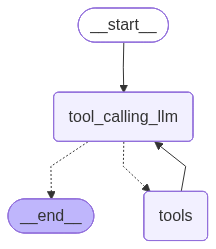

In [41]:
## Node defination
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

## Build Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

##compile the graph
graph = builder.compile()

#View
display(Image(graph.get_graph().draw_mermaid_png()))

In [42]:
messages = graph.invoke({"messages":"1706.03762"})

for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  arxiv (egwrhfnky)
 Call ID: egwrhfnky
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: arxiv

Published: 2023-08-02
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
Summary: The dominant sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder-decoder configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, base
================================== Ai Message ==================================

The paper with arXiv ID [1706.03762](https://arxiv.org/abs/1706.037

In [43]:
messages = graph.invoke({"messages":"Hi I am Aditya"})

for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hi I am Aditya
================================== Ai Message ==================================

Hello Aditya! How can I assist you today?


In [45]:
messages = graph.invoke({"messages":"Hi I am Aditya tell me what happened in Nvidia GTC 2026"})

for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hi I am Aditya tell me what happened in Nvidia GTC 2026
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (2scxbbdzv)
 Call ID: 2scxbbdzv
  Args:
    query: Nvidia GTC 2026 key announcements and events
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "NVIDIA GTC 2026 Highlights: Recap on Everything You Missed", "url": "https://deeperinsights.com/ai-blog/nvidia-gtc-2026-highlights/", "content": "This wasn’t just another hardware event. The agentic + physical AI era began with GTC 2026. In this era, AI systems not only think, but they also act on their own in the digital world and stay safe in the real world. Here’s a full, easy-to-read summary of all the important news, along with clear explanations of what each announcement means and why it’s important.\n\n##